In [1]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
pipeline = joblib.load('../models/fraud_detector.pkl')

df = pd.read_csv('../data/creditcard.csv')
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Model loaded successfully")
print(f"Test set shape: {X_test.shape}")

Model loaded successfully
Test set shape: (56962, 30)


In [3]:
scaler = pipeline.named_steps['scaler']
model = pipeline.named_steps['model']

X_test_scaled = scaler.transform(X_test)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Scaler and model extracted from pipeline")
print(f"Scaled test data shape: {X_test_scaled_df.shape}")

Scaler and model extracted from pipeline
Scaled test data shape: (56962, 30)


In [4]:
explainer = shap.TreeExplainer(model)
print("SHAP explainer created")

SHAP explainer created


In [5]:
X_sample = X_test_scaled_df.iloc[:500]

print("Calculating SHAP values for 500 transactions...")
shap_values = explainer.shap_values(X_sample)
print(f"SHAP values shape: {shap_values.shape}")
print("Done.")

Calculating SHAP values for 500 transactions...
SHAP values shape: (500, 30)
Done.


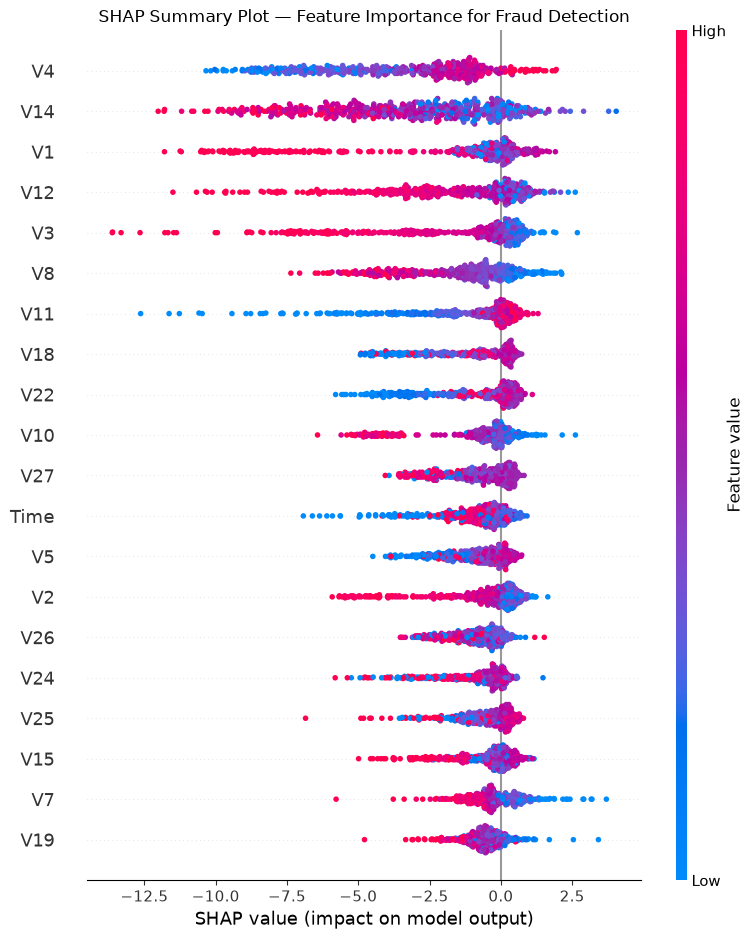

Summary plot saved


In [6]:
plt.figure()
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("SHAP Summary Plot — Feature Importance for Fraud Detection")
plt.tight_layout()
plt.savefig('../notebooks/shap_summary_plot.png', bbox_inches='tight')
plt.show()
print("Summary plot saved")

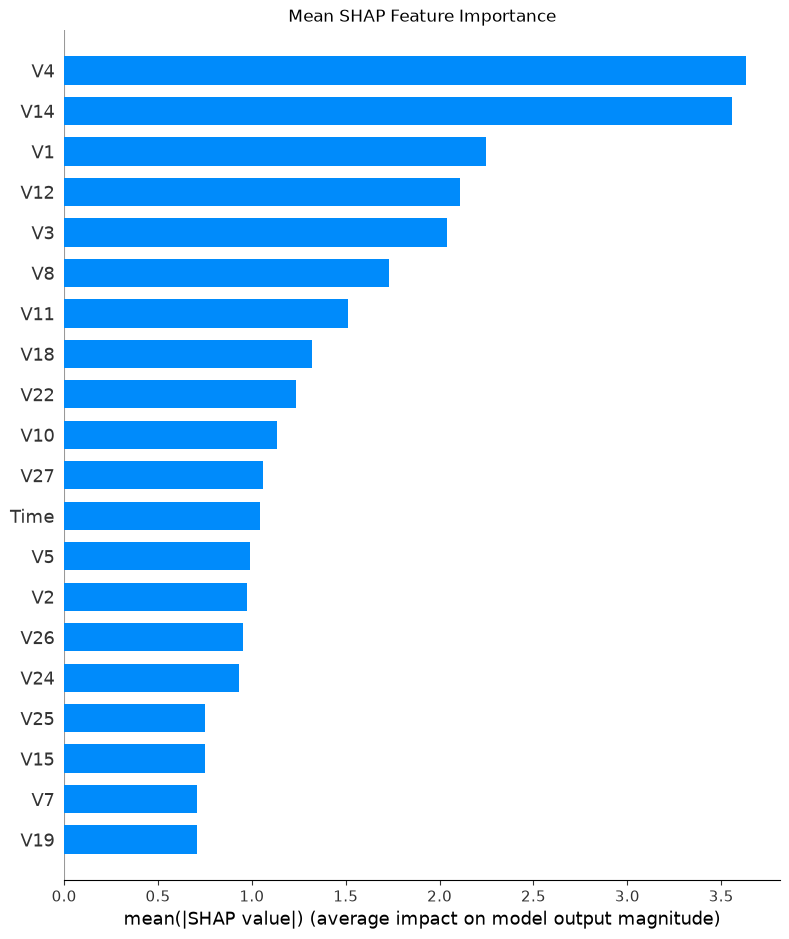

In [8]:
plt.figure()
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False)
plt.title("Mean SHAP Feature Importance")
plt.tight_layout()
plt.savefig('../notebooks/shap_bar_plot.png', bbox_inches='tight')
plt.show()

In [9]:
# find a fraud transaction in the sample
y_test_reset = y_test.reset_index(drop=True)
fraud_indices = y_test_reset.iloc[:500][y_test_reset.iloc[:500] == 1].index.tolist()

print(f"Fraud transactions in sample: {len(fraud_indices)}")
fraud_idx = fraud_indices[0]

shap.initjs()
force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[fraud_idx],
    X_sample.iloc[fraud_idx],
    show=False,
    matplotlib=True
)
plt.savefig('../notebooks/shap_force_plot_fraud.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"Force plot saved for transaction index {fraud_idx}")

Fraud transactions in sample: 0


IndexError: list index out of range